In [68]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize
from qiskit_algorithms import NumPyMinimumEigensolver, VQE, VQD
from qiskit.circuit.library import efficient_su2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.state_fidelities import ComputeUncompute

In [69]:
SEED = 42
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Variational Quantum Eigensolver

The Variational Quantum Eigensolver (VQE) is a hybrid quantum-classical algorithm whose objective is to approximate the ground state of a given Hamiltonian $H$. Hence, its goal is to find a state $|\psi\rangle$ such that:

$$
E_{\psi} = \langle \psi |H|\psi\rangle
$$

is minimized.

It is also possible to estimate this minimum using other algorithms, such as some using Quantum Phase Estimation. The main advantage of VQE over those approaches is that it is better suited to today's NISQ devices, since it uses relatively shallow circuits and does not require fault-tolerant quantum computers.

The VQE is based on the Variational Principle, which states that for any normalized state $|\psi\rangle$, the expected value of the Hamiltonian is always greater than or equal to the true ground-state energy $E_0$:

$$
\langle \psi | H | \psi \rangle \geq E_0
$$

where $E_0$ is the lowest eigenvalue of the Hamiltonian $H$. Equality is only reached when $|\psi\rangle$ is the true ground state of the system.

This principle is the theoretical basis of the VQE algorithm. Instead of trying to directly compute the exact ground state, VQE prepares a family of trial quantum states $|\psi(\theta)\rangle$ using a parametrized quantum circuit. Then, the algorithm searches for the parameters $\theta$ that minimize the expectation value of the Hamiltonian. The closer the ansatz can get to the true ground state, the closer the estimated energy will be to the real minimum energy of the system.

A condition for VQE is that $H$ must be able to be expressed as a linear combination of tensor products of Pauli matrices. This decomposition is important because the expectation value of the Hamiltonian can then be estimated by measuring each Pauli term separately and combining the results. Luckily, this is always the case for observables in finite Hilbert spaces, which are exactly the ones we work with in quantum computing. Given that, the algorithm is quite simple:

- Design a parametrized quantum circuit $V(\theta)$, usually called ansatz.
- With the help of a quantum computer, use the ansatz to prepare the quantum state $|\psi(\theta)\rangle$.
- Measure the prepared state and estimate the energy $E_{\psi(\theta)}$.
- Use a classical optimizer to change the ansatz's parameters in order to minimize the energy.
- Repeat this optimization step until some stopping criterion is met and the optimal parameters $\theta_0$ are found.

Once the algorithm has finished, we can use $\theta_0$ to both find the state of minimum energy:

$$
|\psi(\theta_0)\rangle = V(\theta_0)|0\rangle
$$

and to find the value of the minimum energy:

$$
E_0 = E_{\psi(\theta_0)} = \langle \psi(\theta_0) |H|\psi(\theta_0)\rangle
$$

The choice of the ansatz in VQE is a crucial factor in the algorithm's performance. For this reason, it is important to incorporate domain-specific knowledge of the problem into the design of the ansatz. At the same time, the ansatz should remain shallow and easy to implement, since deep circuits are more affected by noise in current NISQ devices.

# Finding the ground state of a $H_2$ molecule

First, we define our molecular problem, consisting of two hydrogen atoms located at coordinates $(0, 0, -0.37)$ and $(0, 0, 0.37)$, measured in angstroms. The formalism that we will use is second quantization.

In first quantization, the system is described using the coordinates of each electron. Therefore, the wavefunction depends explicitly on the position and spin of every electron:

$$
\Psi(\mathbf{r}_1, \mathbf{r}_2, \ldots, \mathbf{r}_N)
$$

The Hamiltonian is written using the usual physical terms: kinetic energy, attraction between electrons and nuclei, repulsion between electrons, and repulsion between nuclei. This approach is close to the original Schrödinger equation, but it becomes difficult to manage when the number of electrons increases, because the wavefunction has to describe all electrons at the same time.

In second quantization, we do not describe each electron individually. Instead, we describe which orbitals are occupied and which are empty. Each spin orbital can contain either zero or one electron. For example, a state can be written as:

$$
|1100\rangle
$$

where each value indicates whether a spin orbital is occupied or not.

This formalism uses creation and annihilation operators. A creation operator,
$
a_i^\dagger
$
adds an electron to spin orbital $i$, while an annihilation operator,
$
a_i
$
removes an electron from spin orbital $i$.

Using these operators, the electronic Hamiltonian can be written as:

$$
H =
\sum_{pq} h_{pq} a_p^\dagger a_q
+
\frac{1}{2}
\sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s
$$

The first term contains one electron contributions, such as kinetic energy and electron nucleus attraction. The second term contains two electron contributions, mainly electron electron repulsion.

Second quantization is very useful in quantum computing because occupation states can be mapped naturally to qubits. For example, each spin orbital can be associated with one qubit
$
|0\rangle
$
means that the orbital is empty, while
$
|1\rangle
$
means that the orbital is occupied.

Finally, using mappings such as Jordan Wigner, the fermionic Hamiltonian is transformed into a qubit Hamiltonian that can be implemented on a quantum computer.

For the ansatz, first we will use the `efficient_su2` circuit from `qiskit.circuit.library`. It consists of layers of single-qubit rotation gates and entangling gates. The rotation gates create a flexible parametrized quantum state, while the entangling gates introduce correlations between qubits.


The main advantage of `efficient_su2` is that it provides a compact and hardware-efficient circuit, making it suitable for NISQ quantum devices. However, since it is a generic ansatz, it does not explicitly include chemical structure information.

Alternatively, we can use the `UCCSD` ansatz from Qiskit Nature. Unlike `efficient_su2`, this ansatz is chemistry-inspired and is designed specifically for electronic structure problems.

The `UCCSD` ansatz is built using information from the molecular problem, such as the number of particles and the number of spatial orbitals. It usually provides a more physically meaningful trial state than a generic hardware-efficient ansatz, although the resulting circuit can be deeper and more expensive to execute.

In [70]:
# Define the H2 molecule using the PySCF driver
# The two hydrogen atoms are placed along the z axis
driver = PySCFDriver(
    atom="H 0 0 -0.37; H 0 0 0.37",
    basis="sto3g"
)

# Create the molecular problem
problem = driver.run()

# Obtain the electronic Hamiltonian in second quantization
fermionic_hamiltonian = problem.hamiltonian.second_q_op()

# Print the fermionic Hamiltonian
print(fermionic_hamiltonian)

Fermionic Operator
number spin orbitals=4, number terms=36
  -1.2533097866459775 * ( +_0 -_0 )
+ -0.47506884877217787 * ( +_1 -_1 )
+ -1.2533097866459775 * ( +_2 -_2 )
+ -0.47506884877217787 * ( +_3 -_3 )
+ 0.3373779634072241 * ( +_0 +_0 -_0 -_0 )
+ 0.33185570067540676 * ( +_0 +_1 -_1 -_0 )
+ 0.3373779634072241 * ( +_0 +_2 -_2 -_0 )
+ 0.33185570067540676 * ( +_0 +_3 -_3 -_0 )
+ 0.0906052310075985 * ( +_0 +_0 -_1 -_1 )
+ 0.0906052310075985 * ( +_0 +_1 -_0 -_1 )
+ 0.0906052310075985 * ( +_0 +_2 -_3 -_1 )
+ 0.0906052310075985 * ( +_0 +_3 -_2 -_1 )
+ 0.0906052310075985 * ( +_1 +_0 -_1 -_0 )
+ 0.0906052310075985 * ( +_1 +_1 -_0 -_0 )
+ 0.0906052310075985 * ( +_1 +_2 -_3 -_0 )
+ 0.0906052310075985 * ( +_1 +_3 -_2 -_0 )
+ 0.33185570067540676 * ( +_1 +_0 -_0 -_1 )
+ 0.3488257522452313 * ( +_1 +_1 -_1 -_1 )
+ 0.33185570067540676 * ( +_1 +_2 -_2 -_1 )
+ 0.3488257522452313 * ( +_1 +_3 -_3 -_1 )
+ 0.3373779634072241 * ( +_2 +_0 -_0 -_2 )
+ 0.33185570067540676 * ( +_2 +_1 -_1 -_2 )
+ 0.337377963407

In [71]:
# Create the Jordan-Wigner mapper
mapper = JordanWignerMapper()

# Transform the fermionic Hamiltonian into a qubit Hamiltonian
qubit_hamiltonian = mapper.map(fermionic_hamiltonian)

# Print the qubit Hamiltonian
print(qubit_hamiltonian)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81217061+0.j,  0.17141283+0.j, -0.22343154+0.j,  0.17141283+0.j,
 -0.22343154+0.j,  0.12062523+0.j,  0.16868898+0.j,  0.16592785+0.j,
  0.04530262+0.j,  0.04530262+0.j,  0.04530262+0.j,  0.04530262+0.j,
  0.16592785+0.j,  0.17441288+0.j,  0.12062523+0.j])


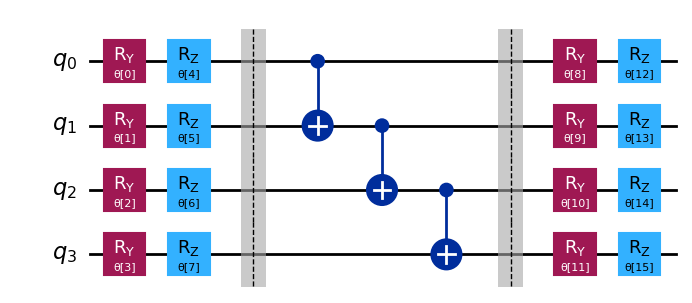

In [72]:
# First, we will use the hardware-efficient ansatz
ansatz = efficient_su2(
    num_qubits=4,
    reps=1,
    entanglement="linear",
    insert_barriers=True
)
ansatz.draw("mpl")

In [73]:
def cost_function(params: list, ansatz, hamiltonian, estimator, cost_history):
    """
    Evaluates the cost function for the given ansatz and cost operator using estimation of the expectation value
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs

    cost_history.append(float(cost))

    return float(cost)

In [74]:
np.random.seed(SEED)

# Transpile the ansatz for the selected backend
ansatz_t = transpile(
    ansatz,
    backend=backend,
    optimization_level=1
)

# Generate random initial parameters
x0 = 2 * np.pi * np.random.random(ansatz_t.num_parameters)

# Create the estimator used to compute expectation values
estimator = Estimator()

# Store the cost values during the optimization
cost_history = []

# Minimize the VQE cost function
result = minimize(
    cost_function,
    x0,
    args=(ansatz_t, qubit_hamiltonian, estimator, cost_history),
    method="COBYQA",
    bounds=[(0, 2*np.pi)] * ansatz_t.num_parameters,
    options={"maxiter": 50, "disp": False},
)

In [75]:
def plot_cost_history(cost_history: list[float], objective: float = None) -> None:
    """
    Plot the cost value at each QAOA optimization iteration given the cost history and objective (optional).
    """
    # Plot the cost history
    plt.figure(figsize=(8, 5))
    plt.plot(cost_history, '-', color='teal', linewidth=2, markersize=5)
    plt.title(f"Evolution of the cost", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("$E$", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot the minimum cost found during the optimization
    min_cost = min(cost_history)
    min_iter = cost_history.index(min_cost)
    plt.scatter(min_iter, min_cost, color='red', s=40, zorder=5, label=f'Minimum: {min_cost:.4f}')

    # Plot objective (if provided)
    if objective is not None:
      plt.axhline(y=objective, color="orange", linestyle="--", label="Objective")
    plt.legend()

    plt.show()

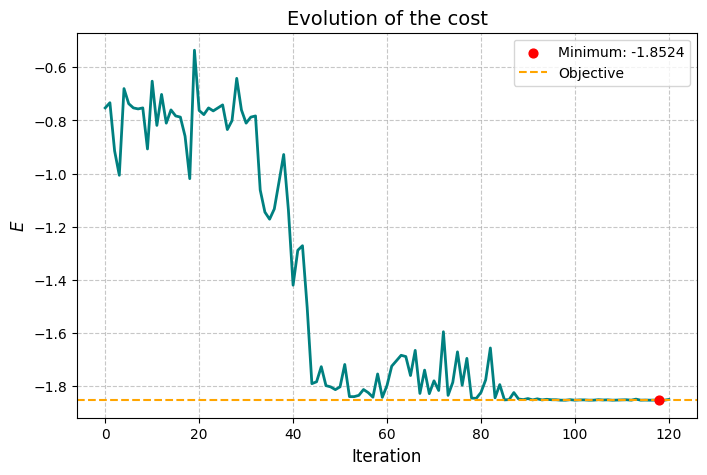

In [76]:
# Compute the exact minimum eigenvalue of the qubit Hamiltonian
solver = NumPyMinimumEigensolver()
result = solver.compute_minimum_eigenvalue(qubit_hamiltonian)

# Plot the VQE cost history and compare it with the exact ground-state energy
plot_cost_history(cost_history, result.eigenvalue)

We can also use the `VQE`class from `qiskit_algorithms`.

In [77]:
# Create and run the VQE solver
optimizer = COBYLA(maxiter=250)
vqe_solver = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=x0
)
vqe_result = vqe_solver.compute_minimum_eigenvalue(qubit_hamiltonian)
print(vqe_result)

{   'aux_operators_evaluated': None,
    'cost_function_evals': 250,
    'eigenvalue': np.float64(-1.852379119442072),
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a58003a42c0>,
    'optimal_parameters': {   ParameterVectorElement(θ[13]): np.float64(1.0409957296626589),
                              ParameterVectorElement(θ[14]): np.float64(0.41107366263909234),
                              ParameterVectorElement(θ[11]): np.float64(6.298310690751474),
                              ParameterVectorElement(θ[12]): np.float64(6.523846392339948),
                              ParameterVectorElement(θ[15]): np.float64(1.3896143535869796),
                              ParameterVectorElement(θ[1]): np.float64(6.283247201882614),
                              ParameterVectorElement(θ[10]): np.float64(-7.893174553933528e-05),
                              ParameterVectorElement(θ[4]): np.float64(1.7791987852687305),
                              ParameterVe

Using `GroundStateEigensolver` from `qiskit_nature.second_q.algorithms`, we can solve the whole electronic problem and get more information than the minimun eigenvalue.

In [78]:
solver = GroundStateEigensolver(mapper, vqe_solver)
res = solver.solve(problem)
print(res)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -1.852379119442
  - computed part:      -1.852379119442
~ Nuclear repulsion energy (Hartree): 0.715104339081
> Total ground state energy (Hartree): -1.137274780361
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 2.000 S: 0.000 S^2: 0.000 M: -0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  0.0]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  -0.000052227794]
    - computed part:      [0.0  0.0  -0.000052227794]
  > Dipole moment (a.u.): [0.0  0.0  0.000052227794]  Total: 0.000052227794
                 (debye): [0.0  0.0  0.000132749798]  Total: 0.000132749798
 


We can see that the result includes the electronic energy, the nuclear repulsion energy, the total ground-state energy, the number of particles, spin-related observables, and dipole moments.

Next, instead of using a generic ansatz such as `EfficientSU2`, we will build a chemistry-inspired ansatz adapted to this electronic structure problem. For this, we use the Hartree-Fock state as the initial state and the `UCCSD` ansatz as the variational circuit.

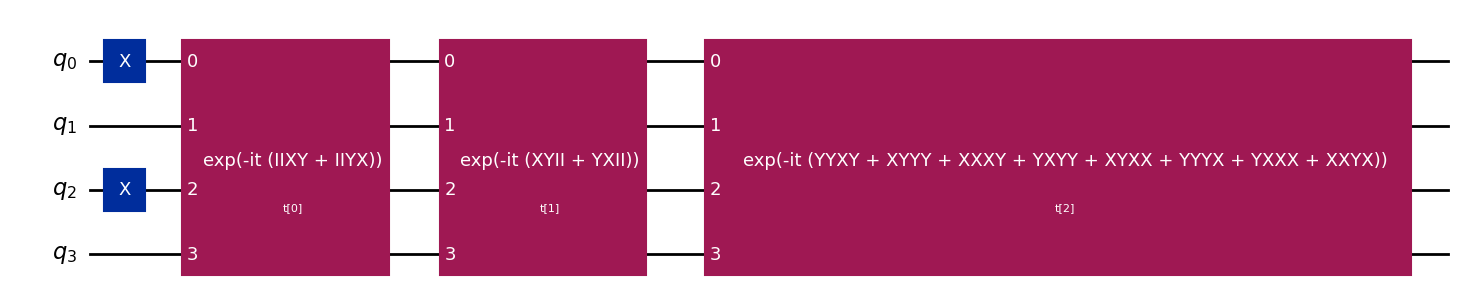

In [79]:
initial_state = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)

UCCSD_ansatz = UCCSD(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state
)

UCCSD_ansatz.decompose().draw("mpl")

In [80]:
UCCSD_vqe = VQE(
    estimator=Estimator(),
    ansatz=UCCSD_ansatz,
    optimizer=optimizer
)

UCCSD_vqe_result = UCCSD_vqe.compute_minimum_eigenvalue(qubit_hamiltonian)
print(UCCSD_vqe_result)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


{   'aux_operators_evaluated': None,
    'cost_function_evals': 64,
    'eigenvalue': np.float64(-1.8523881708791026),
    'optimal_circuit': <qiskit_nature.second_q.circuit.library.ansatzes.uccsd.UCCSD object at 0x7a5800228530>,
    'optimal_parameters': {   ParameterVectorElement(t[1]): np.float64(-1.5707889550715806),
                              ParameterVectorElement(t[2]): np.float64(1.4580231761156308),
                              ParameterVectorElement(t[0]): np.float64(-1.5708543356596232)},
    'optimal_point': array([-1.57085434, -1.57078896,  1.45802318]),
    'optimal_value': np.float64(-1.8523881708791026),
    'optimizer_evals': None,
    'optimizer_result': <qiskit_algorithms.optimizers.optimizer.OptimizerResult object at 0x7a5803211c70>,
    'optimizer_time': 1.7802038192749023}


The `UCCSD` ansatz produces a circuit that is more complex and deeper than the previous `EfficientSU2` circuit. This is because it is specifically designed for electronic structure problems and includes excitation operators motivated by quantum chemistry.

However, in this case the `UCCSD` circuit only has 3 trainable parameters, compared with the 16 parameters of the `EfficientSU2` ansatz. As a result, the classical optimization is easier and faster, since the optimizer has to search in a smaller parameter space.

The final energy obtained is practically the same as with `EfficientSU2`, showing that both ansatzes are able to approximate the ground-state energy of this small molecular system. In this particular simulation, `UCCSD` is faster mainly because optimizing 3 parameters is simpler than optimizing 10.

In a real execution on quantum hardware, this comparison would need to be treated more carefully. Although `UCCSD` has fewer parameters, its greater circuit depth can introduce more noise and gate errors, especially due to the larger number of two-qubit operations. Therefore, a deeper circuit may perform worse on real NISQ devices even if it is more physically motivated.

# Finding excited stated using VQE

With a small modification, we can use VQE to find excited states of $H$. First we need to use standard VQE to find a ground state $|\psi(\theta_0)\rangle = V(\theta_0)|0\rangle$ with energy $\lambda_0$. Then, we design the excited Hamiltonian:

$$
H' = H + C |\psi_0 \rangle \langle \psi_0 |
$$

where C is a positive real number.

We can take any normalized state $|\psi \rangle$ and compute the expectation value:

$$
\langle H'\rangle_{\psi} = \langle \psi |H'|\psi\rangle
=
\langle \psi |H|\psi\rangle
+
C \langle \psi | \psi_0 \rangle \langle \psi_0 | \psi \rangle
=
\langle \psi |H|\psi\rangle
+
C |\langle \psi_0 | \psi \rangle|^2
$$

We can see that the expectation value of $H'$ is the expectation value of $H$ plus a non-negative value that quantifies the overlap of $| \psi \rangle$ and $| \psi_0 \rangle$. That way, we have two extreme cases for that term: if $| \psi \rangle$ = $| \psi_0  \rangle$ that term will be $C$ and if $| \psi \rangle$ and $| \psi_0 \rangle$ are orthogonal, that term will be 0.

It can easily be proven that if $\lambda_0 \leq \lambda_1 \leq ... \lambda_n$ are the eigenvalues of H associated to each eigenvector $\{|\lambda_j \rangle \}$, then:
$$
\langle \lambda_j |H'| \lambda_j \rangle = \lambda_j
$$

when $j \neq 0$ and:

$$
\langle \lambda_0 |H'| \lambda_0 \rangle = C + \lambda_0
$$

Hence if $C>\lambda_1 - \lambda_0$, then $ |\psi_0 \rangle = |\lambda_0\rangle $ will no longer be a ground state of $H'$ because the energy of $|\lambda_1\rangle $ will be lower that of $|\psi_0\rangle $ and consequently, $|\lambda_1\rangle $ must be a ground state of $H'$.

We can use this method to obtain any excited state, not just the first one. For example to find the second excited state, you can consider the Hamiltonian:

$$
H'' = H' + C' |\lambda_1 \rangle \langle \lambda_1 |
$$

and use VQE to obtain $|\lambda_2\rangle$. Exactly as before, it is essential to select an adequate value of $C'$ for this process.

Note that, in order to calculate $|\langle \psi_0 |\psi (\theta) \rangle |^2 $ using a quantum computer, we will take advantage of the fact that:

$$
|\langle \psi_0 |\psi (\theta) \rangle |^2 = |\langle 0|V(\theta_0)^\dagger V(\theta)|0\rangle |^2
$$

Which simply is the probability of obtaining $|0\rangle$ when applying consecutively our ansantz $V$ with $\theta$ as parameters and the inverse of our ansantz $V^\dagger$ with $\theta_0$ as parameters to the state $|0\rangle$. We will implement this operation by using `ComputeUncompute` as the fidelity in `VQD`.

Fist, we will manually build the excited Hamiltonian Hamiltonian $H' = H + C |\psi_0 \rangle \langle \psi_0 |$ and then use the `VQE` class to get the first excited state.

In [81]:
C = 10.0

ground_state_circuit = vqe_result.optimal_circuit.assign_parameters(
    vqe_result.optimal_parameters
)

psi0 = Statevector.from_instruction(ground_state_circuit).data
projector = np.outer(psi0, np.conjugate(psi0))
H_matrix = qubit_hamiltonian.to_matrix()
H_prime_matrix = H_matrix + C * projector
H_prime_operator = SparsePauliOp.from_operator(Operator(H_prime_matrix))


excited_result = vqe_solver.compute_minimum_eigenvalue(H_prime_operator)
print(excited_result)

{   'aux_operators_evaluated': None,
    'cost_function_evals': 250,
    'eigenvalue': np.float64(-1.2491133432348611),
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a58032e2390>,
    'optimal_parameters': {   ParameterVectorElement(θ[8]): np.float64(3.147612222850387),
                              ParameterVectorElement(θ[11]): np.float64(6.158842309066543),
                              ParameterVectorElement(θ[10]): np.float64(1.5705671449202836),
                              ParameterVectorElement(θ[13]): np.float64(1.2705923904947167),
                              ParameterVectorElement(θ[12]): np.float64(6.41940579507),
                              ParameterVectorElement(θ[9]): np.float64(4.4684199371898075),
                              ParameterVectorElement(θ[14]): np.float64(1.821381854751063),
                              ParameterVectorElement(θ[15]): np.float64(1.4367536605180458),
                              ParameterVectorEleme

For a simpler aproach, we could use the `VQD` class to obtain the desired excited state directly.

In [82]:
ansatz = efficient_su2(
    num_qubits=4,
    reps=1,
    entanglement="linear",
    insert_barriers=True
)

optimizer=COBYLA(maxiter=250)
fidelity = ComputeUncompute(sampler)

vqd = VQD(
    estimator=estimator,
    fidelity=fidelity,
    ansatz=ansatz,
    optimizer=optimizer,
    k=2
)

vqd_result = vqd.compute_eigenvalues(qubit_hamiltonian)
print(vqd_result)

{   'aux_operators_evaluated': None,
    'cost_function_evals': array([250, 128]),
    'eigenvalues': array([-1.85238814+0.j, -1.07359472+0.j]),
    'optimal_circuits': [   <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7a58003e3b60>,
    'optimal_parameters': [   {   ParameterVectorElement(θ[3]): np.float64(-3.141549344366361),
                                  ParameterVectorElement(θ[5]): np.float64(0.37142703415574324),
                                  ParameterVectorElement(θ[6]): np.float64(1.541487682624505),
                                  ParameterVectorElement(θ[7]): np.float64(-4.464494645438066),
                                  ParameterVectorElement(θ[8]): np.float64(-0.00014265674400914022),
                                  ParameterVectorElement(θ[9]): np.float64(7.829955583226166e-05),
                                  ParameterVectorElement(θ[10]): np.float64(3.1418424360079213),
                                  ParameterVectorElement(θ[11]): np.float

The manually modified Hamiltonian gives an excited-state energy of approximately:

$$
E_1 \approx -1.2491
$$

Using `VQD`, the two lowest eigenvalues obtained are:

$$
E_0 \approx -1.8319
$$

and

$$
E_1 \approx -1.2433
$$

Both approaches give a very similar value for the first excited state. The main difference is that the manual approach only returns the targeted excited state after modifying the Hamiltonian, while `VQD` directly computes several eigenvalues in sequence. In this case, `VQD` also recovers the ground-state energy and then estimates the first excited state using the overlap penalty internally.

# VQE with Pennylane

Now, we will use PennyLane to find the ground-state energy of the dihydrogen molecule. This problem is very similar to the one solved previously with Qiskit Nature.

In fact, we already obtained a reference value using the `GroundStateEigensolver`:

$$
E_0 = -1.137274780361 \text{ Hartree}
$$

This value includes both the electronic ground-state energy and the nuclear repulsion energy. Therefore, it represents the total ground-state energy of the molecule and can be used as a reference to compare the PennyLane result.

In [83]:
symbols = ["H", "H"]
# Here we use atomic units instead of angstroms
coordinates = np.array([
    0.0, 0.0, -0.6991986158,
    0.0, 0.0,  0.6991986158
])
# Build the molecular Hamiltonian
Hamiltonian, qubits = qml.qchem.molecular_hamiltonian(symbols, coordinates)
print(Hamiltonian)

-0.09706620778648187 * I([0, 1, 2, 3]) + 0.1714128349818368 * Z(0) + 0.1714128349818368 * Z(1) + 0.16868898461465948 * (Z(0) @ Z(1)) + -0.22343155727069636 * Z(2) + 0.12062523781171192 * (Z(0) @ Z(2)) + 0.1659278524199735 * (Z(1) @ Z(2)) + 0.045302614608261585 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.045302614608261585 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.045302614608261585 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.045302614608261585 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.22343155727069636 * Z(3) + 0.1659278524199735 * (Z(0) @ Z(3)) + 0.12062523781171192 * (Z(1) @ Z(3)) + 0.1744128778003259 * (Z(2) @ Z(3))


In [84]:
np.random.seed(SEED)

# Number of qubits used by the molecular Hamiltonian
nqubits = 4

# Create the PennyLane device
# "lightning.qubit" is a fast statevector simulator
# wires indicates the number of qubits available in the circuit
dev = qml.device("lightning.qubit", wires=nqubits)


def EfficientSU2(theta: list[float]) -> None:
    """
    Builds an EfficientSU2-like ansatz using PennyLane gates.
    """
    # First layer of single-qubit rotations
    for i in range(nqubits):
        qml.RY(theta[i], wires=i)
        qml.RZ(theta[i + nqubits], wires=i)

    # Linear entanglement layer
    for i in range(nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Second layer of single-qubit rotations
    for i in range(nqubits):
        qml.RY(theta[i + 2 * nqubits], wires=i)
        qml.RZ(theta[i + 3 * nqubits], wires=i)


# A QNode is a quantum function connected to a PennyLane device
# Every time this function is called, the circuit is executed on dev
@qml.qnode(dev)
def energy(params):
    # Prepare the variational quantum state
    EfficientSU2(params)

    # Return the expectation value of the molecular Hamiltonian
    return qml.expval(Hamiltonian)


# Generate the initial parameters randomly
x0 = 2 * np.pi * np.random.random(4 * nqubits)

# Minimize the energy
result = minimize(
    energy,
    x0,
    method="COBYQA",
    options={"maxiter": 500}
)

# Print the results
print(result)
print("Final energy:", result.fun)
print("Optimal parameters:", result.x)

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -1.1372838351667567
       x: [ 3.367e+00  3.142e+00 ...  4.920e+00  3.150e+00]
     nit: 422
   maxcv: 0.0
    nfev: 586
Final energy: -1.1372838351667567
Optimal parameters: [ 3.36715834e+00  3.14159272e+00  6.28318524e+00  3.14159263e+00
  4.40922166e+00  1.11755071e+00  1.54466248e+00  3.19081806e+00
 -2.88331097e-07  3.14159289e+00  2.35450503e-07  3.14159267e+00
  7.74358177e+00 -4.08231367e+00  4.92025682e+00  3.15023236e+00]


### Conclusion

The PennyLane implementation obtains a final ground-state energy of:

$$
E_0 = -1.137283835167 \text{ Hartree}
$$

This value is extremely close to the reference energy previously obtained with Qiskit Nature using the `GroundStateEigensolver`:

$$
E_0 = -1.1372838351667567 \text{ Hartree}
$$

We can see that noth frameworks are able to reproduce practically the same ground-state energy for the dihydrogen molecule.

The main practical difference is in the workflow. Qiskit Nature provides a more structured chemistry pipeline, with drivers, mappers, eigensolvers and problem-specific results. PennyLane, on the other hand, gives a more direct variational workflow, where the quantum circuit is defined as a differentiable function and optimized manually.
